# Social Media User Segmentation using Unsupervised Machine Learning

## Problem Statement

Social media platforms generate vast amounts of user interaction data without predefined categories. Understanding hidden user groups based on demographics and engagement behavior can help organizations improve targeted marketing, user retention, personalized recommendations, and overall platform performance. This project applies unsupervised machine learning techniques to identify meaningful user segments from Facebook user data.

## Objective :

To apply unsupervised machine learning techniques to segment Facebook users based on their demographic and engagement behavior, compare multiple clustering algorithms, and develop an interactive Streamlit application for predicting user segments and supporting data-driven decision-making.

In [1]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load Dataset

df = pd.read_csv("facebook_data.csv")

In [3]:
# First 5 rows

df.head()

,userid,age,dob_day,dob_year,dob_month,gender,tenure,friend_count,friendships_initiated,likes,likes_received,mobile_likes,mobile_likes_received,www_likes,www_likes_received
0,2094382,14,19,1999,11,male,266.0,0,0,0,0,0,0,0,0
1,1192601,14,2,1999,11,female,6.0,0,0,0,0,0,0,0,0
2,2083884,14,16,1999,11,male,13.0,0,0,0,0,0,0,0,0
3,1203168,14,25,1999,12,female,93.0,0,0,0,0,0,0,0,0
4,1733186,14,4,1999,12,male,82.0,0,0,0,0,0,0,0,0


In [4]:
df[['age',
    'friend_count',
    'friendships_initiated',
    'likes',
    'likes_received']].describe()

,age,friend_count,friendships_initiated,likes,likes_received
count,99003.000000,99003.000000,99003.000000,99003.000000,99003.000000
mean,37.280224,196.350787,107.452471,156.078785,142.689363
std,22.589748,387.304229,188.786951,572.280681,1387.919613
min,13.000000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,31.000000,17.000000,1.000000,1.000000
50%,28.000000,82.000000,46.000000,11.000000,8.000000
75%,50.000000,206.000000,117.000000,81.000000,59.000000
max,113.000000,4923.000000,4144.000000,25111.000000,261197.000000


In [5]:
# Last 5 rows

df.tail()

,userid,age,dob_day,dob_year,dob_month,gender,tenure,friend_count,friendships_initiated,likes,likes_received,mobile_likes,mobile_likes_received,www_likes,www_likes_received
98998,1268299,68,4,1945,4,female,541.0,2118,341,3996,18089,3505,11887,491,6202
98999,1256153,18,12,1995,3,female,21.0,1968,1720,4401,13412,4399,10592,2,2820
99000,1195943,15,10,1998,5,female,111.0,2002,1524,11959,12554,11959,11462,0,1092
99001,1468023,23,11,1990,4,female,416.0,2560,185,4506,6516,4506,5760,0,756
99002,1397896,39,15,1974,5,female,397.0,2049,768,9410,12443,9410,9530,0,2913


In [6]:
# Shape of the dataset

df.shape

(99003, 15)

In [7]:
# Column Names
df.columns

Index(['userid', 'age', 'dob_day', 'dob_year', 'dob_month', 'gender', 'tenure',
       'friend_count', 'friendships_initiated', 'likes', 'likes_received',
       'mobile_likes', 'mobile_likes_received', 'www_likes',
       'www_likes_received'],
      dtype='object')

In [8]:
# Basic information about dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99003 entries, 0 to 99002
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   userid                 99003 non-null  int64  
 1   age                    99003 non-null  int64  
 2   dob_day                99003 non-null  int64  
 3   dob_year               99003 non-null  int64  
 4   dob_month              99003 non-null  int64  
 5   gender                 98828 non-null  object 
 6   tenure                 99001 non-null  float64
 7   friend_count           99003 non-null  int64  
 8   friendships_initiated  99003 non-null  int64  
 9   likes                  99003 non-null  int64  
 10  likes_received         99003 non-null  int64  
 11  mobile_likes           99003 non-null  int64  
 12  mobile_likes_received  99003 non-null  int64  
 13  www_likes              99003 non-null  int64  
 14  www_likes_received     99003 non-null  int64  
dtypes:

In [9]:
# Statistical summary

df.describe().T

,count,mean,std,min,25%,50%,75%,max
userid,99003.0,1.597045e+06,344059.177464,1000008.0,1298805.5,1596148.0,1895744.0,2193542.0
age,99003.0,3.728022e+01,22.589748,13.0,20.0,28.0,50.0,113.0
dob_day,99003.0,1.453041e+01,9.015606,1.0,7.0,14.0,22.0,31.0
dob_year,99003.0,1.975720e+03,22.589748,1900.0,1963.0,1985.0,1993.0,2000.0
dob_month,99003.0,6.283365e+00,3.529672,1.0,3.0,6.0,9.0,12.0
tenure,99001.0,5.378874e+02,457.649874,0.0,226.0,412.0,675.0,3139.0
friend_count,99003.0,1.963508e+02,387.304229,0.0,31.0,82.0,206.0,4923.0
friendships_initiated,99003.0,1.074525e+02,188.786951,0.0,17.0,46.0,117.0,4144.0
likes,99003.0,1.560788e+02,572.280681,0.0,1.0,11.0,81.0,25111.0
likes_received,99003.0,1.426894e+02,1387.919613,0.0,1.0,8.0,59.0,261197.0


## Data Cleaning

In [10]:
# Check missing values

df.isnull().sum()

userid                     0
age                        0
dob_day                    0
dob_year                   0
dob_month                  0
gender                   175
tenure                     2
friend_count               0
friendships_initiated      0
likes                      0
likes_received             0
mobile_likes               0
mobile_likes_received      0
www_likes                  0
www_likes_received         0
dtype: int64

In [11]:
# Check duplicate records

df.duplicated().sum()

np.int64(0)

#### Handle Missing Values

In [12]:
# Fill missing values in gender with the most frequent value

df['gender'] = df['gender'].fillna(df['gender'].mode()[0])

In [13]:
# Fill missing values in tenure with the median

df['tenure'] = df['tenure'].fillna(df['tenure'].median())

In [14]:
df.isnull().sum()

userid                   0
age                      0
dob_day                  0
dob_year                 0
dob_month                0
gender                   0
tenure                   0
friend_count             0
friendships_initiated    0
likes                    0
likes_received           0
mobile_likes             0
mobile_likes_received    0
www_likes                0
www_likes_received       0
dtype: int64



The dataset contained a small number of missing values in the `gender` and `tenure` columns. Since the missing values represented only a tiny fraction of the dataset, they were imputed instead of removing rows. The `gender` column was filled using the mode (most frequent category), while the `tenure` column was filled using the median to preserve the distribution and reduce the influence of outliers.

In [15]:
# Check datatypes

df.dtypes

userid                     int64
age                        int64
dob_day                    int64
dob_year                   int64
dob_month                  int64
gender                    object
tenure                   float64
friend_count               int64
friendships_initiated      int64
likes                      int64
likes_received             int64
mobile_likes               int64
mobile_likes_received      int64
www_likes                  int64
www_likes_received         int64
dtype: object

In [16]:
# Unique values in each column

for col in df.columns:
    print(f"{col}:{df[col].nunique()}")

userid:99003
age:101
dob_day:31
dob_year:101
dob_month:12
gender:2
tenure:2426
friend_count:2562
friendships_initiated:1519
likes:2924
likes_received:2681
mobile_likes:2396
mobile_likes_received:2004
www_likes:1726
www_likes_received:1636


In [17]:
# Gender Distribution:

df['gender'].value_counts()

gender
male      58749
female    40254
Name: count, dtype: int64

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the structure, distribution, and relationships within the dataset. This helps identify patterns, detect anomalies, and select appropriate features for clustering.

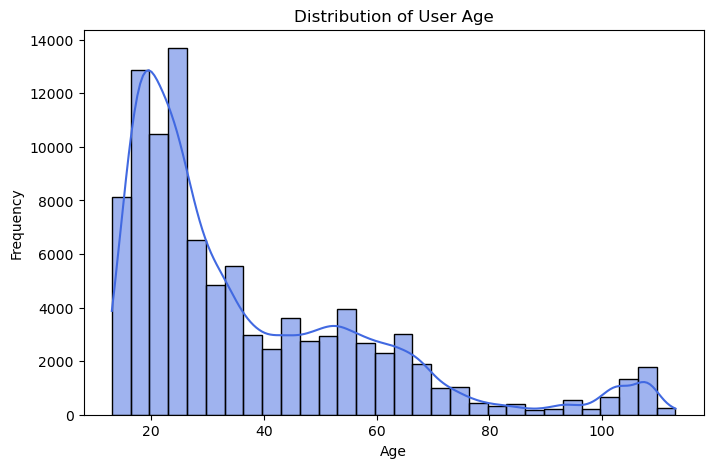

In [18]:
# Age Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True, color='royalblue')

plt.title('Distribution of User Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


### Insight

- The age of Facebook users ranges from 13 to 113 years.
- The average age of users is approximately 37 years.
- Most users are concentrated between 18 and 35 years, indicating that young adults form the largest user group.
- The distribution is positively (right) skewed, with the number of users decreasing as age increases.
- A small number of users have ages above 100 years, which represent extreme values in the dataset.
Since clustering algorithms are sensitive to differences in feature scales, the age feature will be standardized before applying the clustering models

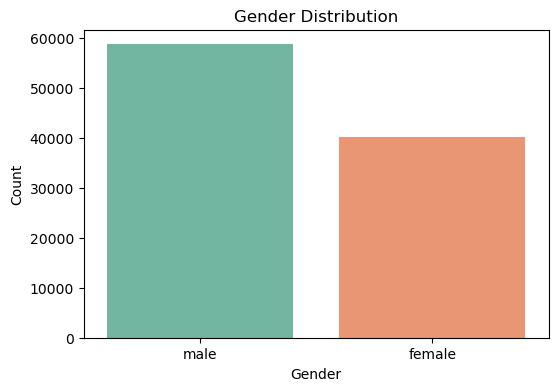

In [21]:
# Count plot for Gender Distribution

plt.figure(figsize=(6,4))
sns.countplot(
    data=df,
    x='gender',
    hue='gender',
    palette='Set2',
    legend=False)
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

### Insight

- The dataset contains both male and female Facebook users.
- Male users constitute the majority of the dataset, with a noticeably higher count than female users.
- Female users represent a smaller proportion but still account for a significant share of the dataset.
- The gender distribution is moderately imbalanced, indicating that the dataset contains more male users than female users.
- Since gender is a categorical feature, it will be encoded into numerical values before being used in clustering algorithms.

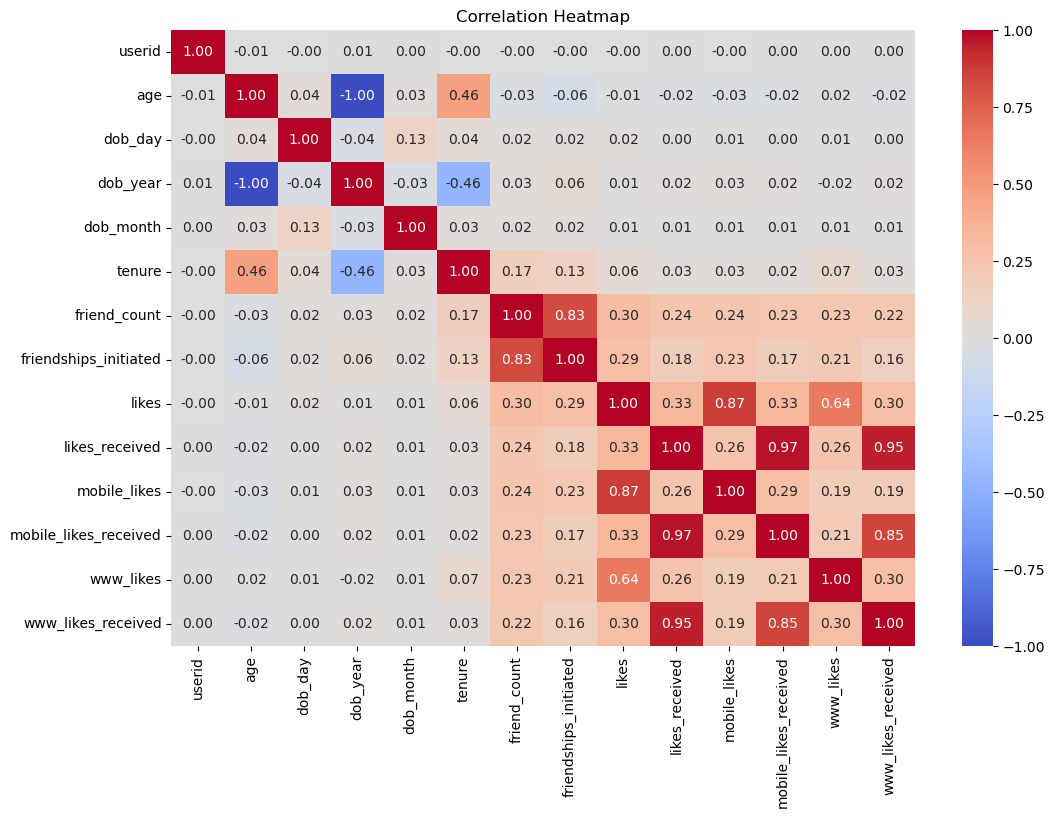

In [19]:
# Correlation Heatmap

plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Heatmap")
plt.show()

### Insights from Correlation Heatmap

- The heatmap shows the strength and direction of relationships between numerical features in the Facebook dataset.
- friend_count and friendships_initiated exhibit a strong positive correlation (0.83), indicating that users with more friends tend to initiate more     friendships.
- likes and mobile_likes have a strong positive correlation (0.87), suggesting that most user likes are generated through mobile devices.
- likes_received and mobile_likes_received show a very strong positive correlation (0.97), indicating that likes received are predominantly from         mobile interactions.
- likes_received and www_likes_received are also highly correlated (0.95), showing consistency in engagement across different platforms.
- mobile_likes_received and www_likes_received have a strong positive correlation (0.85), suggesting that users receiving engagement on one platform     are also likely to receive engagement on the other.
- age and dob_year have a perfect negative correlation (-1.00) because age is directly calculated from the year of birth. To avoid redundant             information and multicollinearity, only one of these features should be retained during feature selection.
- Most other feature pairs show weak to moderate correlations, indicating that they capture different aspects of user behavior and can provide           valuable information for clustering.

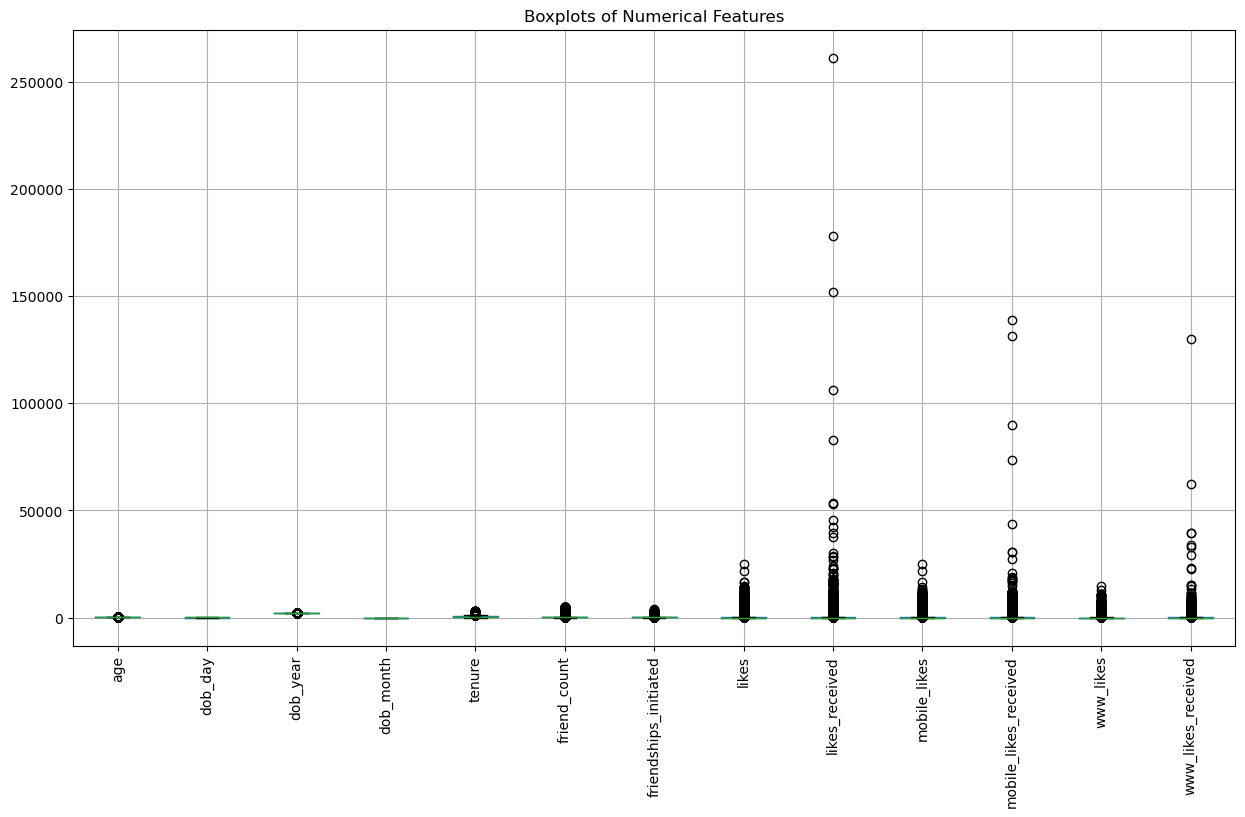

In [20]:
# Boxplot of Numerical Features

numeric_cols = df.select_dtypes(include='number').drop(columns=['userid']).columns

plt.figure(figsize=(15,8))
df[numeric_cols].boxplot(rot=90)
plt.title("Boxplots of Numerical Features")
plt.show()

### Insight

- The boxplots reveal that several numerical features contain outliers, particularly friend_count, friendships_initiated, likes, likes_received,        mobile_likes, mobile_likes_received, www_likes, and www_likes_received.
- The likes_received feature exhibits the largest number of extreme values, indicating that a small group of users receive significantly more likes     than the majority of users.
- Engagement-related features show a high degree of variability, reflecting differences in user activity and interaction levels across the Facebook     platform.
- The demographic features (age, dob_day, dob_month, dob_year) contain relatively fewer outliers compared to the engagement-related features.
- These outliers are expected in social media datasets because some users are naturally more active and popular than others.
- Since clustering algorithms are sensitive to differences in feature scales, the numerical features will be standardized before clustering. The        detected outliers will be retained as they represent genuine user behavior rather than data entry errors.

## Feature Selection

In [20]:
# Drop Unnecessary Columns

df = df.drop(columns=['userid', 'dob_day', 'dob_month', 'dob_year'])

In [22]:
# Check remaining columns

df.columns

Index(['age', 'gender', 'tenure', 'friend_count', 'friendships_initiated',
       'likes', 'likes_received', 'mobile_likes', 'mobile_likes_received',
       'www_likes', 'www_likes_received'],
      dtype='object')

In [23]:
# Encode the Gender Column

df['gender'] = df['gender'].map({
    'male': 0,
    'female': 1
})

In [24]:
# Verify Data Types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99003 entries, 0 to 99002
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    99003 non-null  int64  
 1   gender                 99003 non-null  int64  
 2   tenure                 99003 non-null  float64
 3   friend_count           99003 non-null  int64  
 4   friendships_initiated  99003 non-null  int64  
 5   likes                  99003 non-null  int64  
 6   likes_received         99003 non-null  int64  
 7   mobile_likes           99003 non-null  int64  
 8   mobile_likes_received  99003 non-null  int64  
 9   www_likes              99003 non-null  int64  
 10  www_likes_received     99003 non-null  int64  
dtypes: float64(1), int64(10)
memory usage: 8.3 MB


In [25]:
# Cteate Copy for Profiling

profile_df = df.copy()

In [26]:
# Log Transformation

import numpy as np

skewed_cols = [
    'friend_count',
    'friendships_initiated',
    'likes',
    'likes_received',
    'mobile_likes',
    'mobile_likes_received',
    'www_likes',
    'www_likes_received'
]

df[skewed_cols] = np.log1p(df[skewed_cols])

In [27]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

In [28]:
# Convert it back to a DataFrame:

scaled_df = pd.DataFrame(
    scaled_data,
    columns=df.columns
)

scaled_df.head()

,age,gender,tenure,friend_count,friendships_initiated,likes,likes_received,mobile_likes,mobile_likes_received,www_likes,www_likes_received
0,-1.030571,-0.82776,-0.594098,-2.805176,-2.514942,-1.212076,-1.158113,-0.986706,-1.044315,-0.631188,-0.927881
1,-1.030571,1.20808,-1.162226,-2.805176,-2.514942,-1.212076,-1.158113,-0.986706,-1.044315,-0.631188,-0.927881
2,-1.030571,-0.82776,-1.146930,-2.805176,-2.514942,-1.212076,-1.158113,-0.986706,-1.044315,-0.631188,-0.927881
3,-1.030571,1.20808,-0.972121,-2.805176,-2.514942,-1.212076,-1.158113,-0.986706,-1.044315,-0.631188,-0.927881
4,-1.030571,-0.82776,-0.996158,-2.805176,-2.514942,-1.212076,-1.158113,-0.986706,-1.044315,-0.631188,-0.927881


### K-Means Clustering

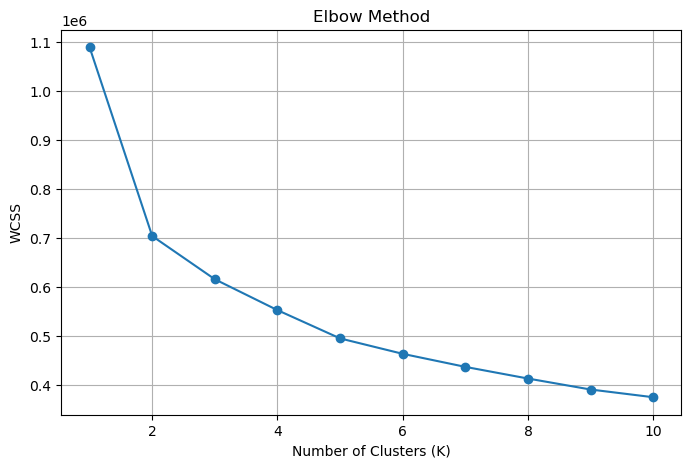

In [29]:
# Find the Optimal Number of Clusters (Elbow Method)

from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

### Insights for Elbow Method

- The Within-Cluster Sum of Squares (WCSS) decreases as the number of clusters (K) increases, indicating that adding more clusters improves cluster compactness.
- A noticeable elbow point is observed around K = 4, where the rate of decrease in WCSS begins to slow down.
- After K = 4, the improvement in WCSS becomes gradual, suggesting that adding more clusters provides only marginal benefits.
- Based on the Elbow Method, 4 clusters appear to be the optimal choice for segmenting Facebook users.
- Therefore, K = 4 will be selected for the K-Means clustering model and further validated using the Silhouette Score.

### Model Evaluation

In [30]:
# Silhouette Score
from sklearn.metrics import silhouette_score

# Take a random sample of 10,000 rows
sample_df = scaled_df.sample(n=10000, random_state=42)

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(sample_df)

    score = silhouette_score(sample_df, labels)
    silhouette_scores.append(score)

print(silhouette_scores)

[0.32509411509382696, 0.20016462538126828, 0.19746557630110345, 0.18093002278558962, 0.19025957324653972, 0.1831941599199683, 0.18923603685310772, 0.19382969790358093, 0.18971696994652565]


- The Silhouette Score was used to evaluate the quality of clustering for different values of K.
- The highest Silhouette Score (0.318) was obtained when K = 2, indicating the best cluster separation according to this metric.
- The Silhouette Score gradually decreases as the number of clusters increases, suggesting that additional clusters reduce the separation between       groups.
- Although K = 2 provides the highest score, the Elbow Method indicates that K = 4 offers a more meaningful segmentation of Facebook users.
- Therefore, K = 4 was selected for K-Means clustering because it provides a better balance between clustering performance and interpretability.

In [31]:
scaled_df = scaled_df.drop(columns=['KMeans_Cluster'], errors='ignore')


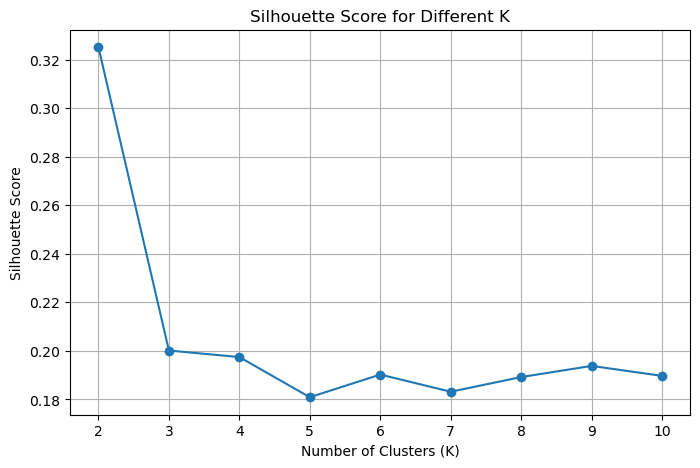

In [32]:
#  Plot the Silhouette Scores

plt.figure(figsize=(8,5))
plt.plot(range(2,11), silhouette_scores, marker='o')
plt.title("Silhouette Score for Different K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

### Insights 

- The Silhouette Score was used to evaluate the quality of clustering for different numbers of clusters (K).
- The highest Silhouette Score (≈ 0.318) was obtained at K = 2, indicating the strongest cluster separation according to this metric.
- The Silhouette Score gradually decreases as the number of clusters increases, suggesting that additional clusters reduce the separation between       user groups.
- Although K = 2 provides the highest Silhouette Score, it results in only two broad user segments, which may not capture the diversity of user         behavior.
- The Elbow Method identified K = 4 as the optimal number of clusters by balancing model complexity and within-cluster compactness.
- Therefore, K = 4 was selected for the K-Means clustering model because it provides more meaningful and interpretable user segments while              maintaining acceptable clustering performance.

In [33]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df['KMeans_Cluster'] = kmeans.fit_predict(scaled_df)

df.head()

,age,gender,tenure,friend_count,friendships_initiated,likes,likes_received,mobile_likes,mobile_likes_received,www_likes,www_likes_received,KMeans_Cluster
0,14,0,266.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,14,1,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,14,0,13.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,14,1,93.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,14,0,82.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [34]:
df['KMeans_Cluster'].value_counts()

KMeans_Cluster
1    38994
3    30052
2    17931
0    12026
Name: count, dtype: int64

In [35]:
# Davies-Bouldin Index

from sklearn.metrics import davies_bouldin_score

db_score = davies_bouldin_score(scaled_df, df['KMeans_Cluster'])

print("Davies-Bouldin Index:", db_score)

Davies-Bouldin Index: 1.5813012937900883


In [36]:
for k in [3, 4]:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(scaled_df)

    print(f"K = {k}")
    print(pd.Series(labels).value_counts())
    print()

K = 3
1    40775
2    37129
0    21099
Name: count, dtype: int64

K = 4
1    38994
3    30052
2    17931
0    12026
Name: count, dtype: int64



### PCA Visualization

In [37]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_df)
pca_df = pd.DataFrame(
    pca_components,
    columns=['PC1', 'PC2']
)

pca_df['Cluster'] = df['KMeans_Cluster']

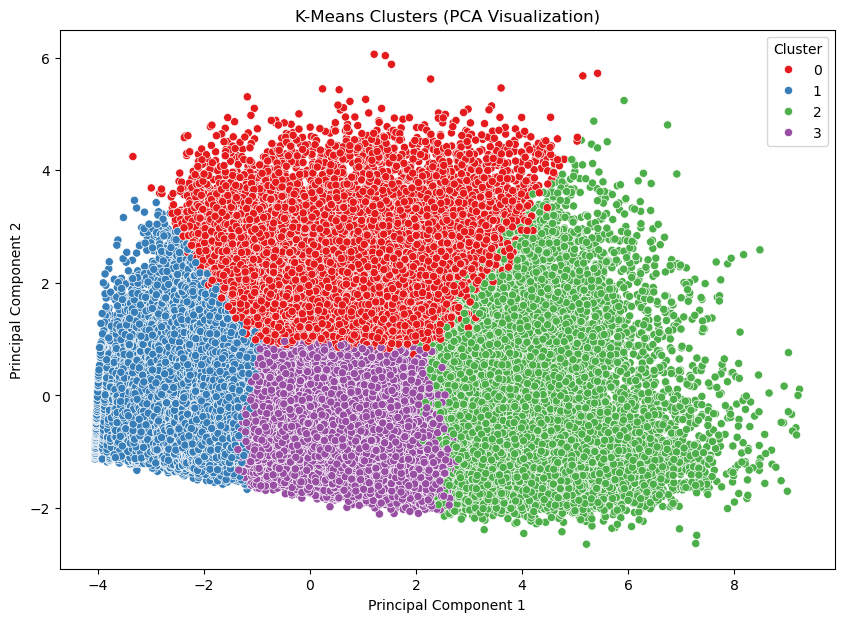

In [38]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1',
    s=35
)

plt.title("K-Means Clusters (PCA Visualization)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

### Insights

- The PCA visualization reduces the multidimensional dataset into two principal components, making it easier to visualize the clusters.
- Four distinct clusters are visible after applying PCA for dimensionality reduction.
- Most user groups are reasonably well separated, indicating that K-Means successfully identified meaningful segments.
- A small amount of overlap exists between some clusters, which is expected after projecting high-dimensional data into two principal components.
- The PCA visualization supports the effectiveness of the K-Means clustering model in grouping users with similar behavioral characteristics.

In [40]:
# Explained Variance

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.50608093 0.13309931]


### Hierarchical Clustering

In [43]:
# Import Libraries

from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering

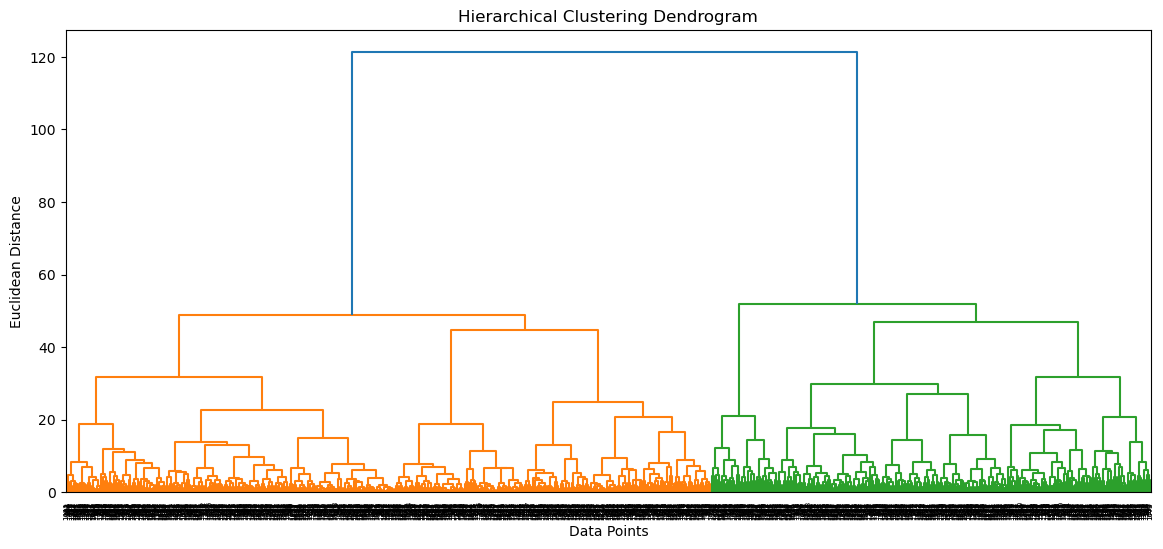

In [44]:
# Create the Dendrogram

sample_hc = scaled_df.sample(n=2000, random_state=42)

plt.figure(figsize=(14,6))

dendrogram(
    linkage(sample_hc, method='ward')
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

### Insights

- The dendrogram illustrates the hierarchical merging process of data points based on their similarity.
- Each vertical line represents the distance at which two clusters are merged.
- Clusters that merge at lower linkage distances are more similar, whereas clusters merged at higher distances are more distinct.
- A noticeable increase in the linkage distance indicates the presence of well-separated clusters within the dataset.
- Based on the dendrogram, the dataset can be reasonably partitioned into four clusters, which supports the cluster selection used in the               Hierarchical Clustering model.
- The Ward linkage method was used, which minimizes the variance within each cluster and helps create compact, homogeneous clusters.

In [45]:
# Train Hierarchical Clustering

sample_hc = scaled_df.sample(n=2000, random_state=42)

from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=4,
    linkage='ward'
)

hc_labels = hc.fit_predict(sample_hc)

In [46]:
sample_hc_df = sample_hc.copy()
sample_hc_df['HC_Cluster'] = hc_labels

### Model Evaluation

In [47]:
# Silhouette Score

from sklearn.metrics import silhouette_score, davies_bouldin_score

hc_silhouette = silhouette_score(sample_hc, hc_labels)
hc_db = davies_bouldin_score(sample_hc, hc_labels)

print("Hierarchical Silhouette Score:", hc_silhouette)
print("Hierarchical Davies-Bouldin Index:", hc_db)

Hierarchical Silhouette Score: 0.16268227525161924
Hierarchical Davies-Bouldin Index: 1.7654604428949385


### Insights 

- Hierarchical Clustering was applied using Ward linkage with 4 clusters.
- Due to the large size of the dataset, a random sample of 2,000 observations (or 1,000 if that is what you actually used) was selected to reduce       computational complexity.
- The model achieved a Silhouette Score of 0.163, indicating moderate separation between the identified clusters.
- The Davies-Bouldin Index of 1.765 suggests that some clusters overlap and are not as compact as desired.
- Compared to K-Means, Hierarchical Clustering produced more balanced cluster sizes, but its overall clustering quality was lower based on the          evaluation metrics.
- These results indicate that K-Means performs better than Hierarchical Clustering for this Facebook user dataset.

### DBSCAN Clustering

In [48]:
#Import DBSCAN

from sklearn.cluster import DBSCAN

In [49]:
# Model Training

sample_db = sample_hc.copy()

dbscan = DBSCAN(
    eps=0.8,
    min_samples=10
)

db_labels = dbscan.fit_predict(sample_db)

In [50]:
# Add Cluster Labels

sample_db_df = sample_db.copy()
sample_db_df['DBSCAN_Cluster'] = db_labels

In [51]:
# Cluster Distribution

sample_db_df['DBSCAN_Cluster'].value_counts()

DBSCAN_Cluster
-1    1503
 0     414
 1      62
 2      21
Name: count, dtype: int64

In [52]:
# Number of Clusters

print("Number of clusters:",
      len(set(db_labels)) - (1 if -1 in db_labels else 0))

Number of clusters: 3


In [53]:
# Number of Noise Points

print("Noise Points:",
      list(db_labels).count(-1))

Noise Points: 1503


### Model Evaluation

In [54]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

mask = db_labels != -1

if len(set(db_labels[mask])) > 1:

    db_silhouette = silhouette_score(
        sample_db[mask],
        db_labels[mask]
    )

    db_index = davies_bouldin_score(
        sample_db[mask],
        db_labels[mask]
    )

    print("Silhouette Score:", db_silhouette)
    print("Davies-Bouldin Index:", db_index)

else:
    print("DBSCAN did not produce enough clusters for evaluation.")

Silhouette Score: 0.19034411680328953
Davies-Bouldin Index: 1.0503156985451183


| Metric                   |     Value |
| ------------------------ | --------: |
| **Silhouette Score**     | **0.190** |
| **Davies-Bouldin Index** | **1.050** |


### Insights

- The DBSCAN model achieved a Silhouette Score of 0.190, indicating moderate cluster separation.
- The Davies-Bouldin Index of 1.050 is lower than that of Hierarchical Clustering, suggesting that DBSCAN produced more compact and better-separated     clusters.
- DBSCAN effectively identified outliers without requiring the number of clusters to be specified in advance.
- Compared to Hierarchical Clustering, DBSCAN produced slightly better clustering quality based on the Davies-Bouldin Index.

### PCA Visualization

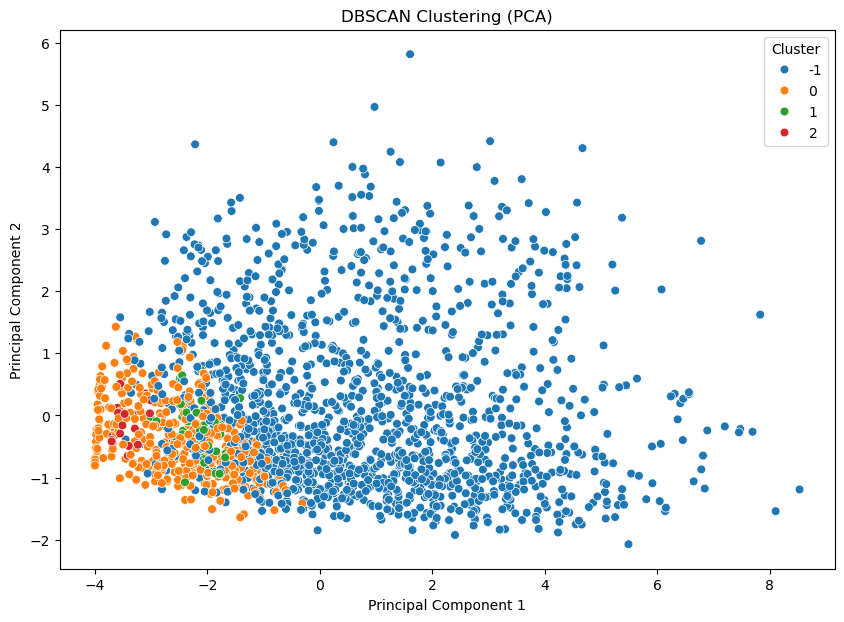

In [55]:

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

db_pca = pca.fit_transform(sample_db)

db_pca_df = pd.DataFrame(
    db_pca,
    columns=['PC1', 'PC2']
)

db_pca_df['Cluster'] = db_labels

# Plot

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=db_pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='tab10',
    s=40
)

plt.title("DBSCAN Clustering (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

### Insights

- The PCA plot visualizes the DBSCAN clustering results in two dimensions.
- The blue points (Cluster -1) represent noise points (outliers) that DBSCAN could not assign to any dense cluster.
- Three dense clusters were identified, representing groups of users with similar engagement behavior.
- The noise points are widely scattered, indicating that these users have unusual or isolated behavioral patterns.
- Unlike K-Means, DBSCAN can naturally detect outliers without forcing every observation into a cluster.
- Some overlap between clusters is visible due to dimensionality reduction using PCA.

### Cluster Profiling

In [56]:
# Calculate Cluster Statistics

profile_df['KMeans_Cluster'] = df['KMeans_Cluster']
cluster_profile = profile_df.groupby('KMeans_Cluster').mean().round(2)
cluster_profile

,age,gender,tenure,friend_count,friendships_initiated,likes,likes_received,mobile_likes,mobile_likes_received,www_likes,www_likes_received
KMeans_Cluster,,,,,,,,,,,
0,76.90,0.49,1249.75,208.68,102.20,62.41,38.75,29.65,21.11,32.76,17.64
1,33.01,0.26,382.41,53.55,33.20,3.76,1.58,2.24,0.91,1.52,0.67
2,34.33,0.73,635.99,510.79,255.42,716.53,703.18,480.66,411.79,235.87,291.40
3,28.72,0.38,396.22,189.09,117.62,56.81,32.96,48.03,21.80,8.78,11.15


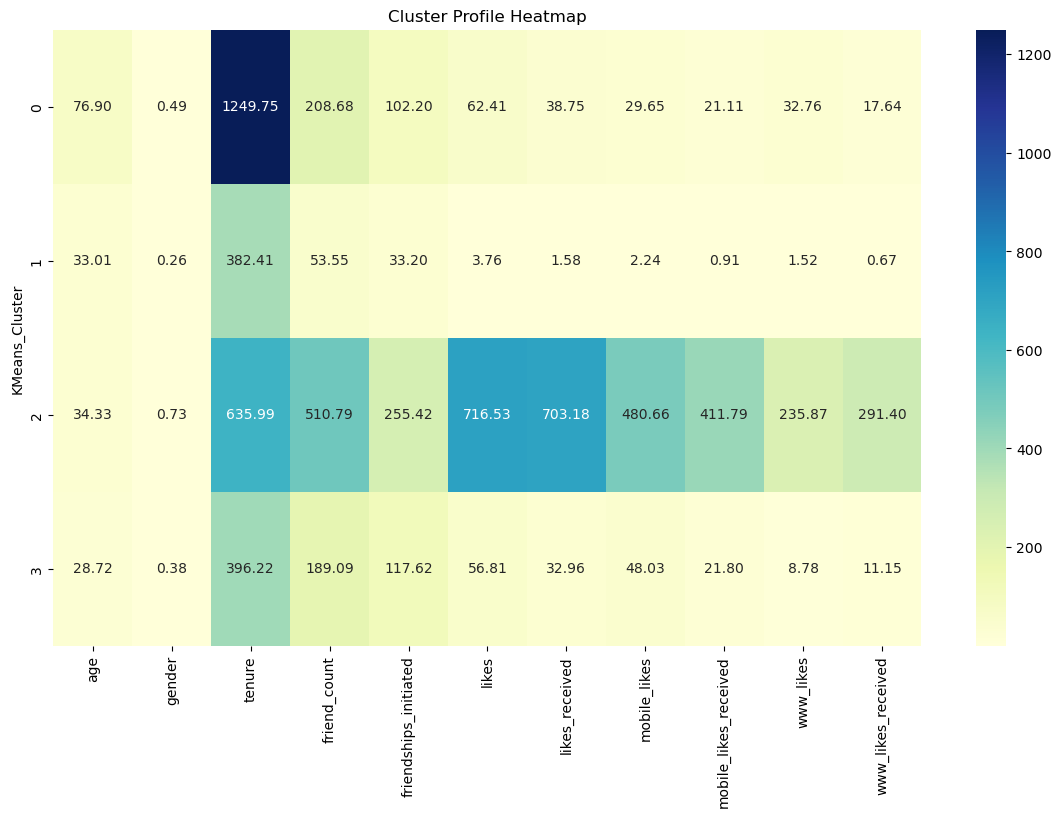

In [57]:
# Visualize the Profile

plt.figure(figsize=(14,8))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)

plt.title("Cluster Profile Heatmap")
plt.show()

## Cluster Interpretation

##### Cluster 0 – Casual Users

- Moderate age
- Medium account tenure
- Very low friend count
- Low engagement (likes and likes received)
  
**Insight:** These users use Facebook occasionally with minimal interaction.

**Business Action:** Increase engagement through personalized recommendations and notifications.

#### Cluster 1 – Highly Engaged Users

- Young users
- Highest engagement
- High likes received
- Active on mobile and web

**Insight:** These are the platform's most active users.

**Business Action:** Target them with premium features, creator tools, and advertisements.

#### Cluster 2 – Senior Low-Activity Users

- Oldest users
- Long account tenure
- Low interaction

**Insight:** Experienced Facebook users who rarely engage.

**Business Action:** Recommend memories, family content, and simplified features.

#### Cluster 3 – Socially Active Users

- Moderate age
- High friend count
- Good engagement
- Long account tenure
  
**Insight:** Regular users who actively interact with friends and communities.

**Business Action:** Recommend groups, events, and community-based content.

## Conclusion

This project successfully applied unsupervised machine learning techniques to segment Facebook users based on their demographic and engagement characteristics. Three clustering algorithms—K-Means, Hierarchical Clustering, and DBSCAN—were implemented and evaluated using the Silhouette Score and Davies-Bouldin Index. Among them, K-Means produced the most meaningful and interpretable user segments. The identified clusters reveal distinct user behaviors, ranging from casual users to highly engaged users, providing valuable insights that can support personalized recommendations, targeted marketing, and improved user engagement strategies.

## Pipeline Development and Model Export

In [58]:
# Select Final Features

features = [
    'age',
    'gender',
    'tenure',
    'friend_count',
    'friendships_initiated',
    'likes',
    'likes_received',
    'mobile_likes',
    'mobile_likes_received',
    'www_likes',
    'www_likes_received'
]

X = df[features]

X.head()

,age,gender,tenure,friend_count,friendships_initiated,likes,likes_received,mobile_likes,mobile_likes_received,www_likes,www_likes_received
0,14,0,266.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,14,1,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,14,0,13.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,14,1,93.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,14,0,82.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [59]:
# Build the Machine Learning Pipeline

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(
        n_clusters=4,
        random_state=42,
        n_init=10
    ))
])

pipeline.fit(X)

,steps,"[('scaler', ...), ('kmeans', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_clusters,4
,init,'k-means++'
,n_init,10
,max_iter,300


In [60]:
# Save the Pipeline

import joblib

joblib.dump(
    pipeline,
    "facebook_segmentation_pipeline.pkl"
)

print("Pipeline saved successfully!")

Pipeline saved successfully!


In [61]:
# Load the Saved Pipeline

loaded_pipeline = joblib.load(
    "facebook_user_segmentation_pipeline.pkl"
)

print("Pipeline loaded successfully!")

Pipeline loaded successfully!


In [62]:
# Test the Pipeline

sample_user = X.iloc[[0]]

predicted_cluster = loaded_pipeline.predict(sample_user)

print("Predicted Cluster:", predicted_cluster[0])

Predicted Cluster: 1


In [63]:
# Predict a New User

new_user = pd.DataFrame({
    "age":[25],
    "gender":[1],
    "tenure":[350],
    "friend_count":[500],
    "friendships_initiated":[220],
    "likes":[150],
    "likes_received":[180],
    "mobile_likes":[120],
    "mobile_likes_received":[140],
    "www_likes":[30],
    "www_likes_received":[40]
})

prediction = loaded_pipeline.predict(new_user)

print("Predicted Cluster:", prediction[0])

Predicted Cluster: 2


A machine learning pipeline was developed using StandardScaler for feature scaling and K-Means Clustering for user segmentation. The pipeline was trained using the selected Facebook user features and exported as a .pkl file using Joblib. This exported pipeline can be directly integrated into a Streamlit application to classify new Facebook users into their respective clusters.

## Streamlit Application Development

#### Import required libraries

- import streamlit as st
- import pandas as pd
- import joblib

#### Configure the Application

Configure the application title, icon, and layout using Streamlit's page configuration settings to create a user-friendly interface.

#### Load the Saved Pipeline

Load the exported K-Means clustering pipeline so it can predict the cluster for new users without retraining the model.

#### Create the User Input Interface

Design an interactive sidebar where users can enter their Facebook profile details, including:

- Age
- Gender
- Tenure
- Friend Count
- Friendships Initiated
- Likes
- Likes Received
- Mobile Likes
- Mobile Likes Received
- Web Likes
- Web Likes Received

#### Prepare the Input Data

Convert the user-entered values into a Pandas DataFrame with the same feature order used during model training.

#### Predict the User Segment

prediction = pipeline.predict(input_data)

Use the trained K-Means pipeline to predict the Facebook user segment based on the entered information.

#### Display the Prediction Results

Display the predicted user segment along with:

- Cluster name
- User segment description
- Business recommendation
- Input summary

This helps users understand the characteristics of the predicted cluster.

#### Run the Application

streamlit run app.py

Launch the Streamlit application locally using the above command.

#### Deploy the Application

Deploy the completed Streamlit application on Streamlit Community Cloud to make it publicly accessible via a web browser.

## Conclusion

A user-friendly Streamlit application was successfully developed by integrating the trained K-Means clustering pipeline. The application allows users to enter Facebook profile information, predicts the corresponding user segment, and provides meaningful descriptions and business recommendations. The final application offers an interactive platform for analyzing Facebook user behavior and demonstrates the end-to-end deployment of an unsupervised machine learning solution.